# 知乎点赞用户-回答用户网络检查

该 notebook 只作为交互检查界面；正式逻辑在 `network/build_network.py`、`network/metrics.py` 和 `network/visualize.py` 中。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'network':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from shared.data_loader import load_network_answers
from network.build_network import run
from network import config

pd.set_option('display.max_colwidth', 120)

## 生成或刷新输出

In [2]:
# 如需重新从 Excel 构建网络，取消下一行注释。
# result = run()

answers = load_network_answers()
answer_likes = pd.read_csv(config.ANSWER_LIKE_DETAILS_CSV, keep_default_na=False)
edges = pd.read_csv(config.USER_EDGE_LIST_CSV, keep_default_na=False)
nodes = pd.read_csv(config.NODE_METRICS_CSV, keep_default_na=False)
network_metrics = pd.read_csv(config.NETWORK_METRICS_CSV, keep_default_na=False)
quality = pd.read_csv(config.QUALITY_REPORT_CSV, keep_default_na=False)

## 总览指标

In [3]:
summary = pd.DataFrame([
    {'metric': '原始回答数量', 'value': len(answers)},
    {'metric': '解析出的回答级点赞记录数', 'value': len(answer_likes)},
    {'metric': '聚合后的用户-用户边数', 'value': len(edges)},
    {'metric': '独立回答用户数', 'value': answer_likes['author'].nunique()},
    {'metric': '独立点赞用户数', 'value': answer_likes['liker'].nunique()},
    {'metric': '网络用户节点数', 'value': nodes['user'].nunique()},
])
display(summary)
display(network_metrics)
display(quality)

,metric,value
0,原始回答数量,1250
1,解析出的回答级点赞记录数,45819
2,聚合后的用户-用户边数,45616
3,独立回答用户数,1082
4,独立点赞用户数,20072
5,网络用户节点数,20934


,scope,node_count,edge_count,density,weakly_connected_component_count,largest_weakly_connected_component_size
0,directed_full_graph,20934,45616,0.000104,62,20787


,metric,value
0,answer_level_like_records,45819
1,answers_missing_author,1
2,answers_with_parsed_likes,1094
3,answers_without_liker_list,155
4,duplicate_likers_within_answer,332
5,raw_answer_rows,1250
6,removed_duplicate_or_invalid_records,333
7,self_like_records_removed,1
8,unique_answer_authors,1082
9,unique_likers,20072


## 节点指标与 Opinion Leaders

In [4]:
display(nodes.head(20))
display(nodes.sort_values(['in_degree', 'pagerank'], ascending=False).head(20))
display(nodes.sort_values('pagerank', ascending=False).head(20))

,user,in_degree,out_degree,pagerank,is_answer_author,is_liker
0,王克丹,1979,0,0.031650,True,False
1,远月半子,1977,0,0.020191,True,False
2,王子君,1976,0,0.028579,True,False
3,古都闲云,1649,0,0.023372,True,False
4,Jayus,1636,0,0.015132,True,False
5,盖因斯iFortune,1582,0,0.023406,True,False
6,路人丙,1223,2,0.009878,True,True
7,走资派是狗,1109,0,0.008060,True,False
8,布ling,1091,0,0.009000,True,False
9,山东精神病院院长,1073,0,0.008546,True,False


,user,in_degree,out_degree,pagerank,is_answer_author,is_liker
0,王克丹,1979,0,0.031650,True,False
1,远月半子,1977,0,0.020191,True,False
2,王子君,1976,0,0.028579,True,False
3,古都闲云,1649,0,0.023372,True,False
4,Jayus,1636,0,0.015132,True,False
5,盖因斯iFortune,1582,0,0.023406,True,False
6,路人丙,1223,2,0.009878,True,True
7,走资派是狗,1109,0,0.008060,True,False
8,布ling,1091,0,0.009000,True,False
9,山东精神病院院长,1073,0,0.008546,True,False


,user,in_degree,out_degree,pagerank,is_answer_author,is_liker
0,王克丹,1979,0,0.031650,True,False
2,王子君,1976,0,0.028579,True,False
5,盖因斯iFortune,1582,0,0.023406,True,False
3,古都闲云,1649,0,0.023372,True,False
1,远月半子,1977,0,0.020191,True,False
4,Jayus,1636,0,0.015132,True,False
10,Gaarmat,870,0,0.011218,True,False
13,阳光下的沈同学,670,0,0.010633,True,False
11,只道当时是寻常,864,0,0.010586,True,False
14,QiJi2018,652,0,0.009966,True,False


## 边权检查

In [5]:
display(edges.sort_values('interaction_count', ascending=False).head(30))
display(edges['interaction_count'].describe())

,liker,author,interaction_count
14,万万木想到,springsun,2
15,不是,springsun,2
199,科罗廖夫,驲崩舔黄,2
47,知乎用户,springsun,2
200,给我一东的时间,驲崩舔黄,2
201,蘇藍,驲崩舔黄,2
23,努力向太阳,springsun,2
202,龟举意识,驲崩舔黄,2
0,1450大工程,springsun,2
1,ABC,springsun,2


count    45616.000000
mean         1.004450
std          0.066562
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: interaction_count, dtype: float64

## 网络图

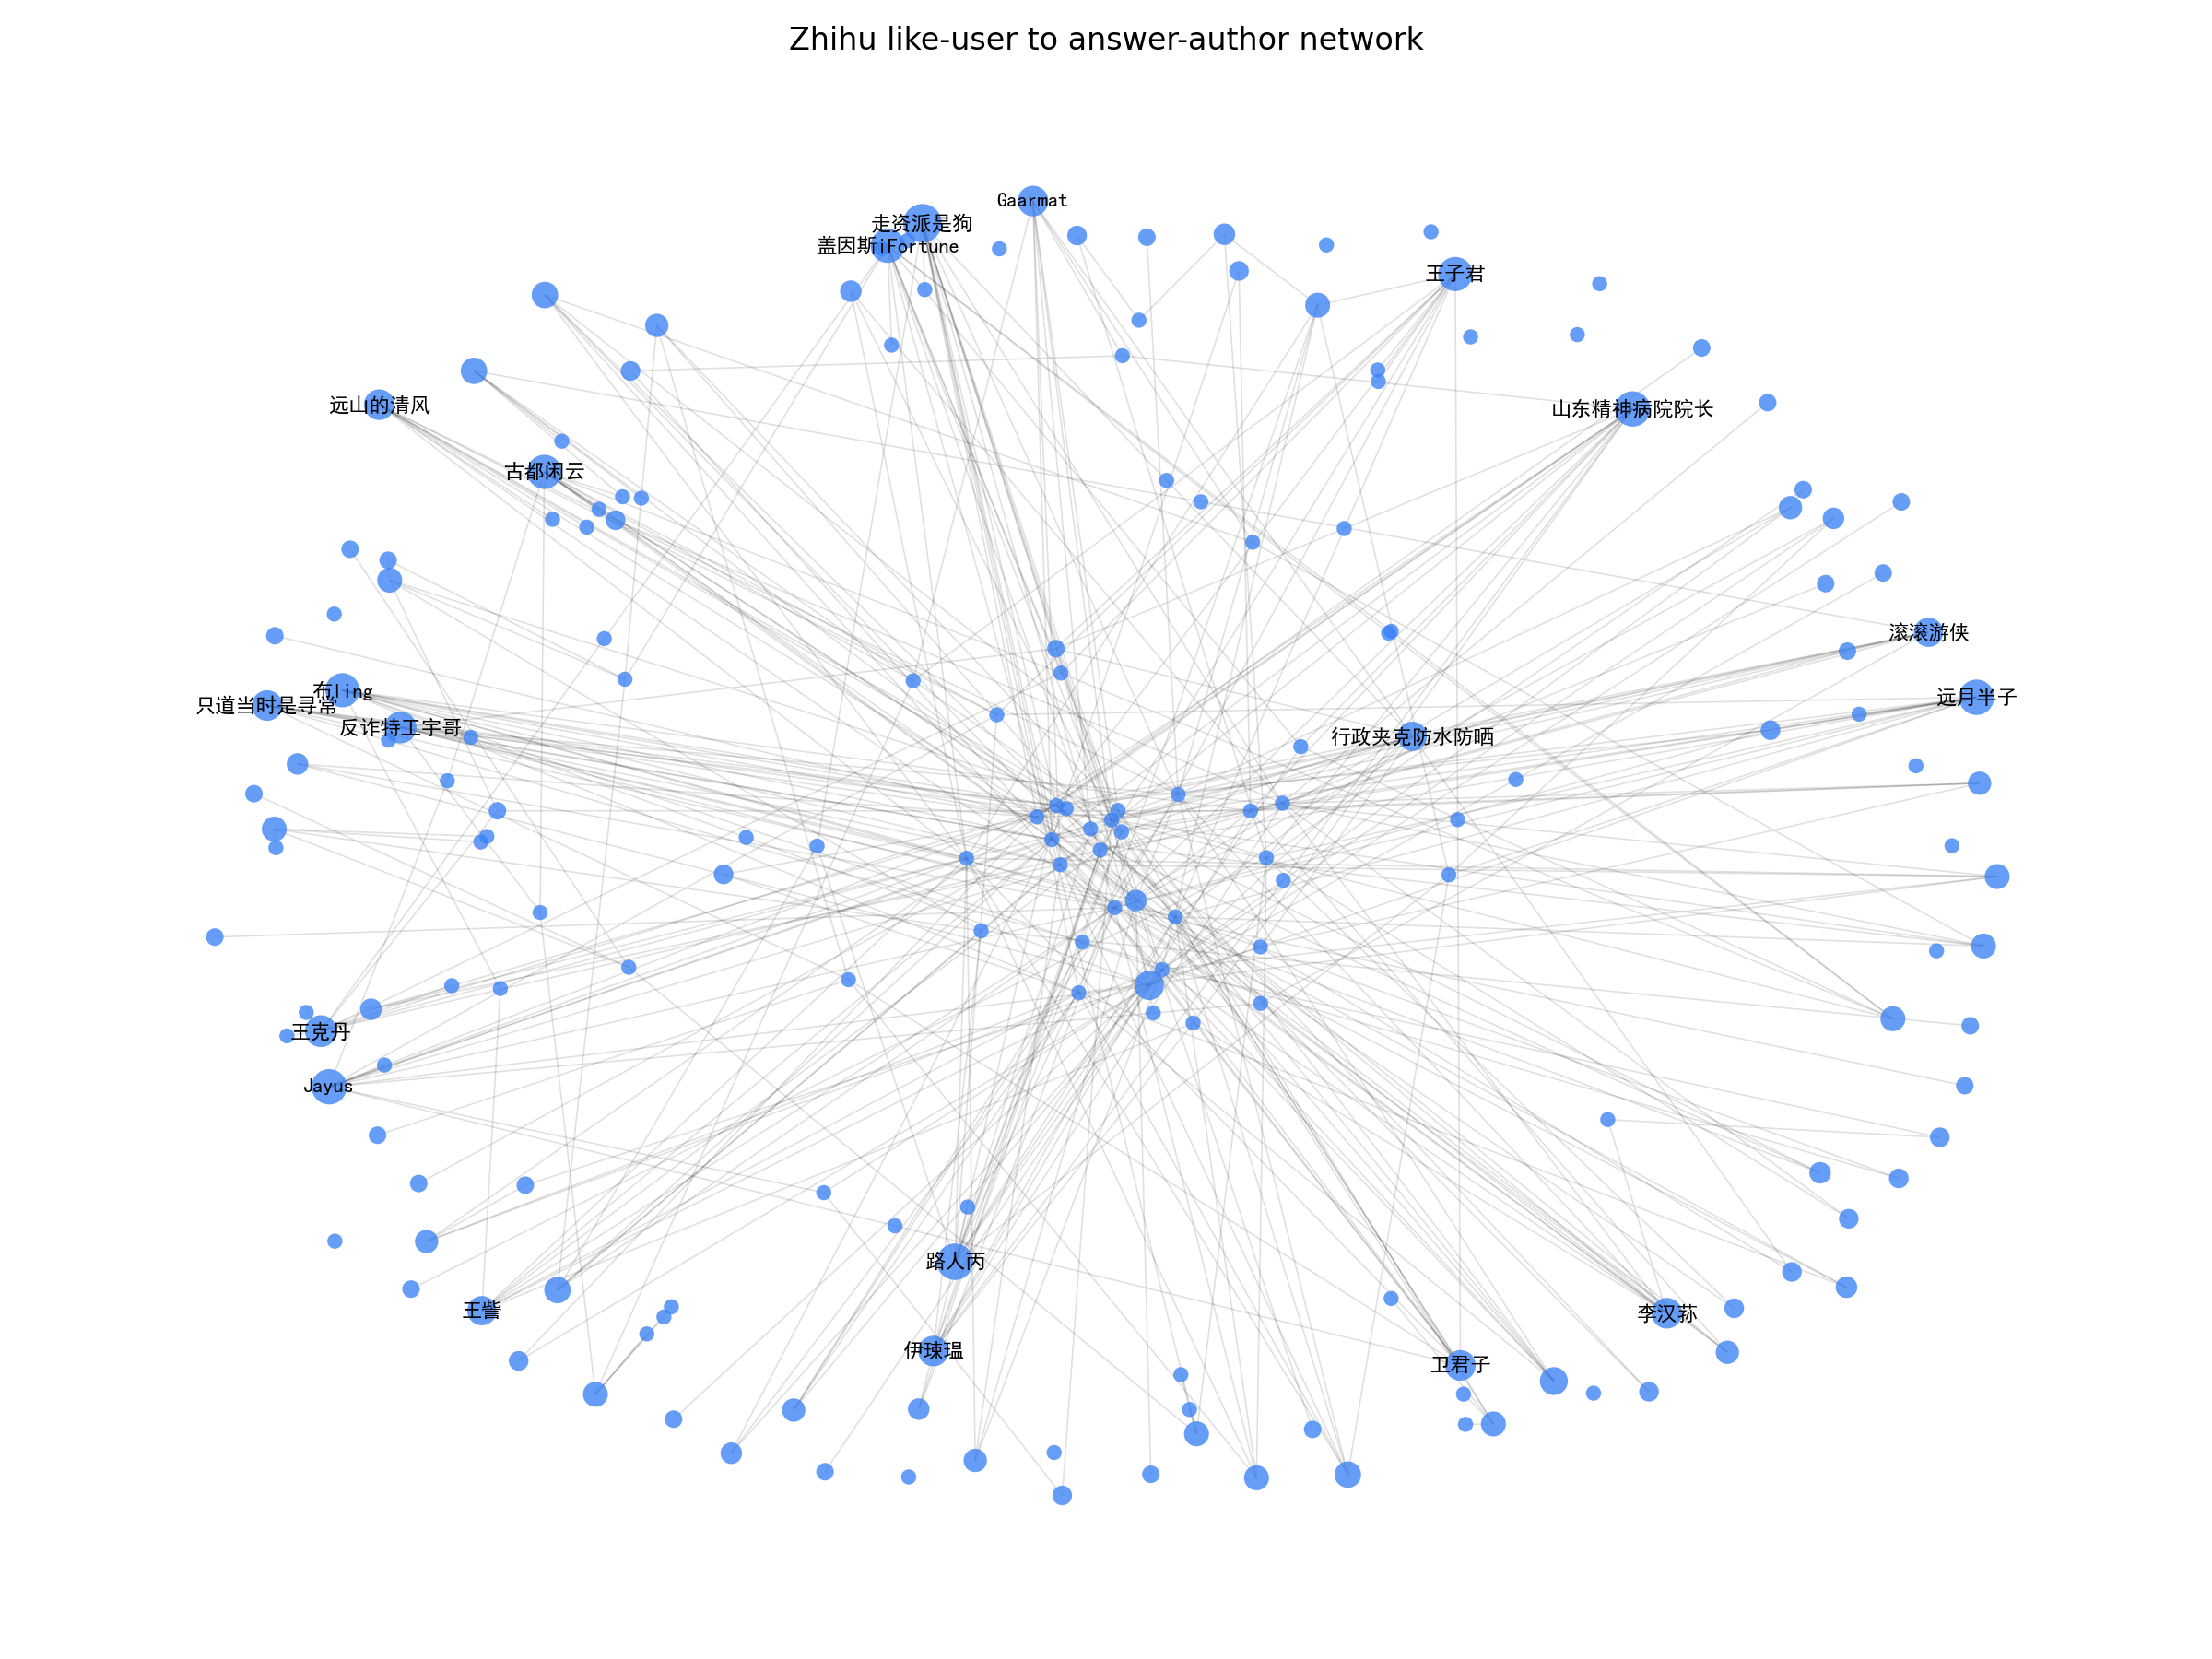

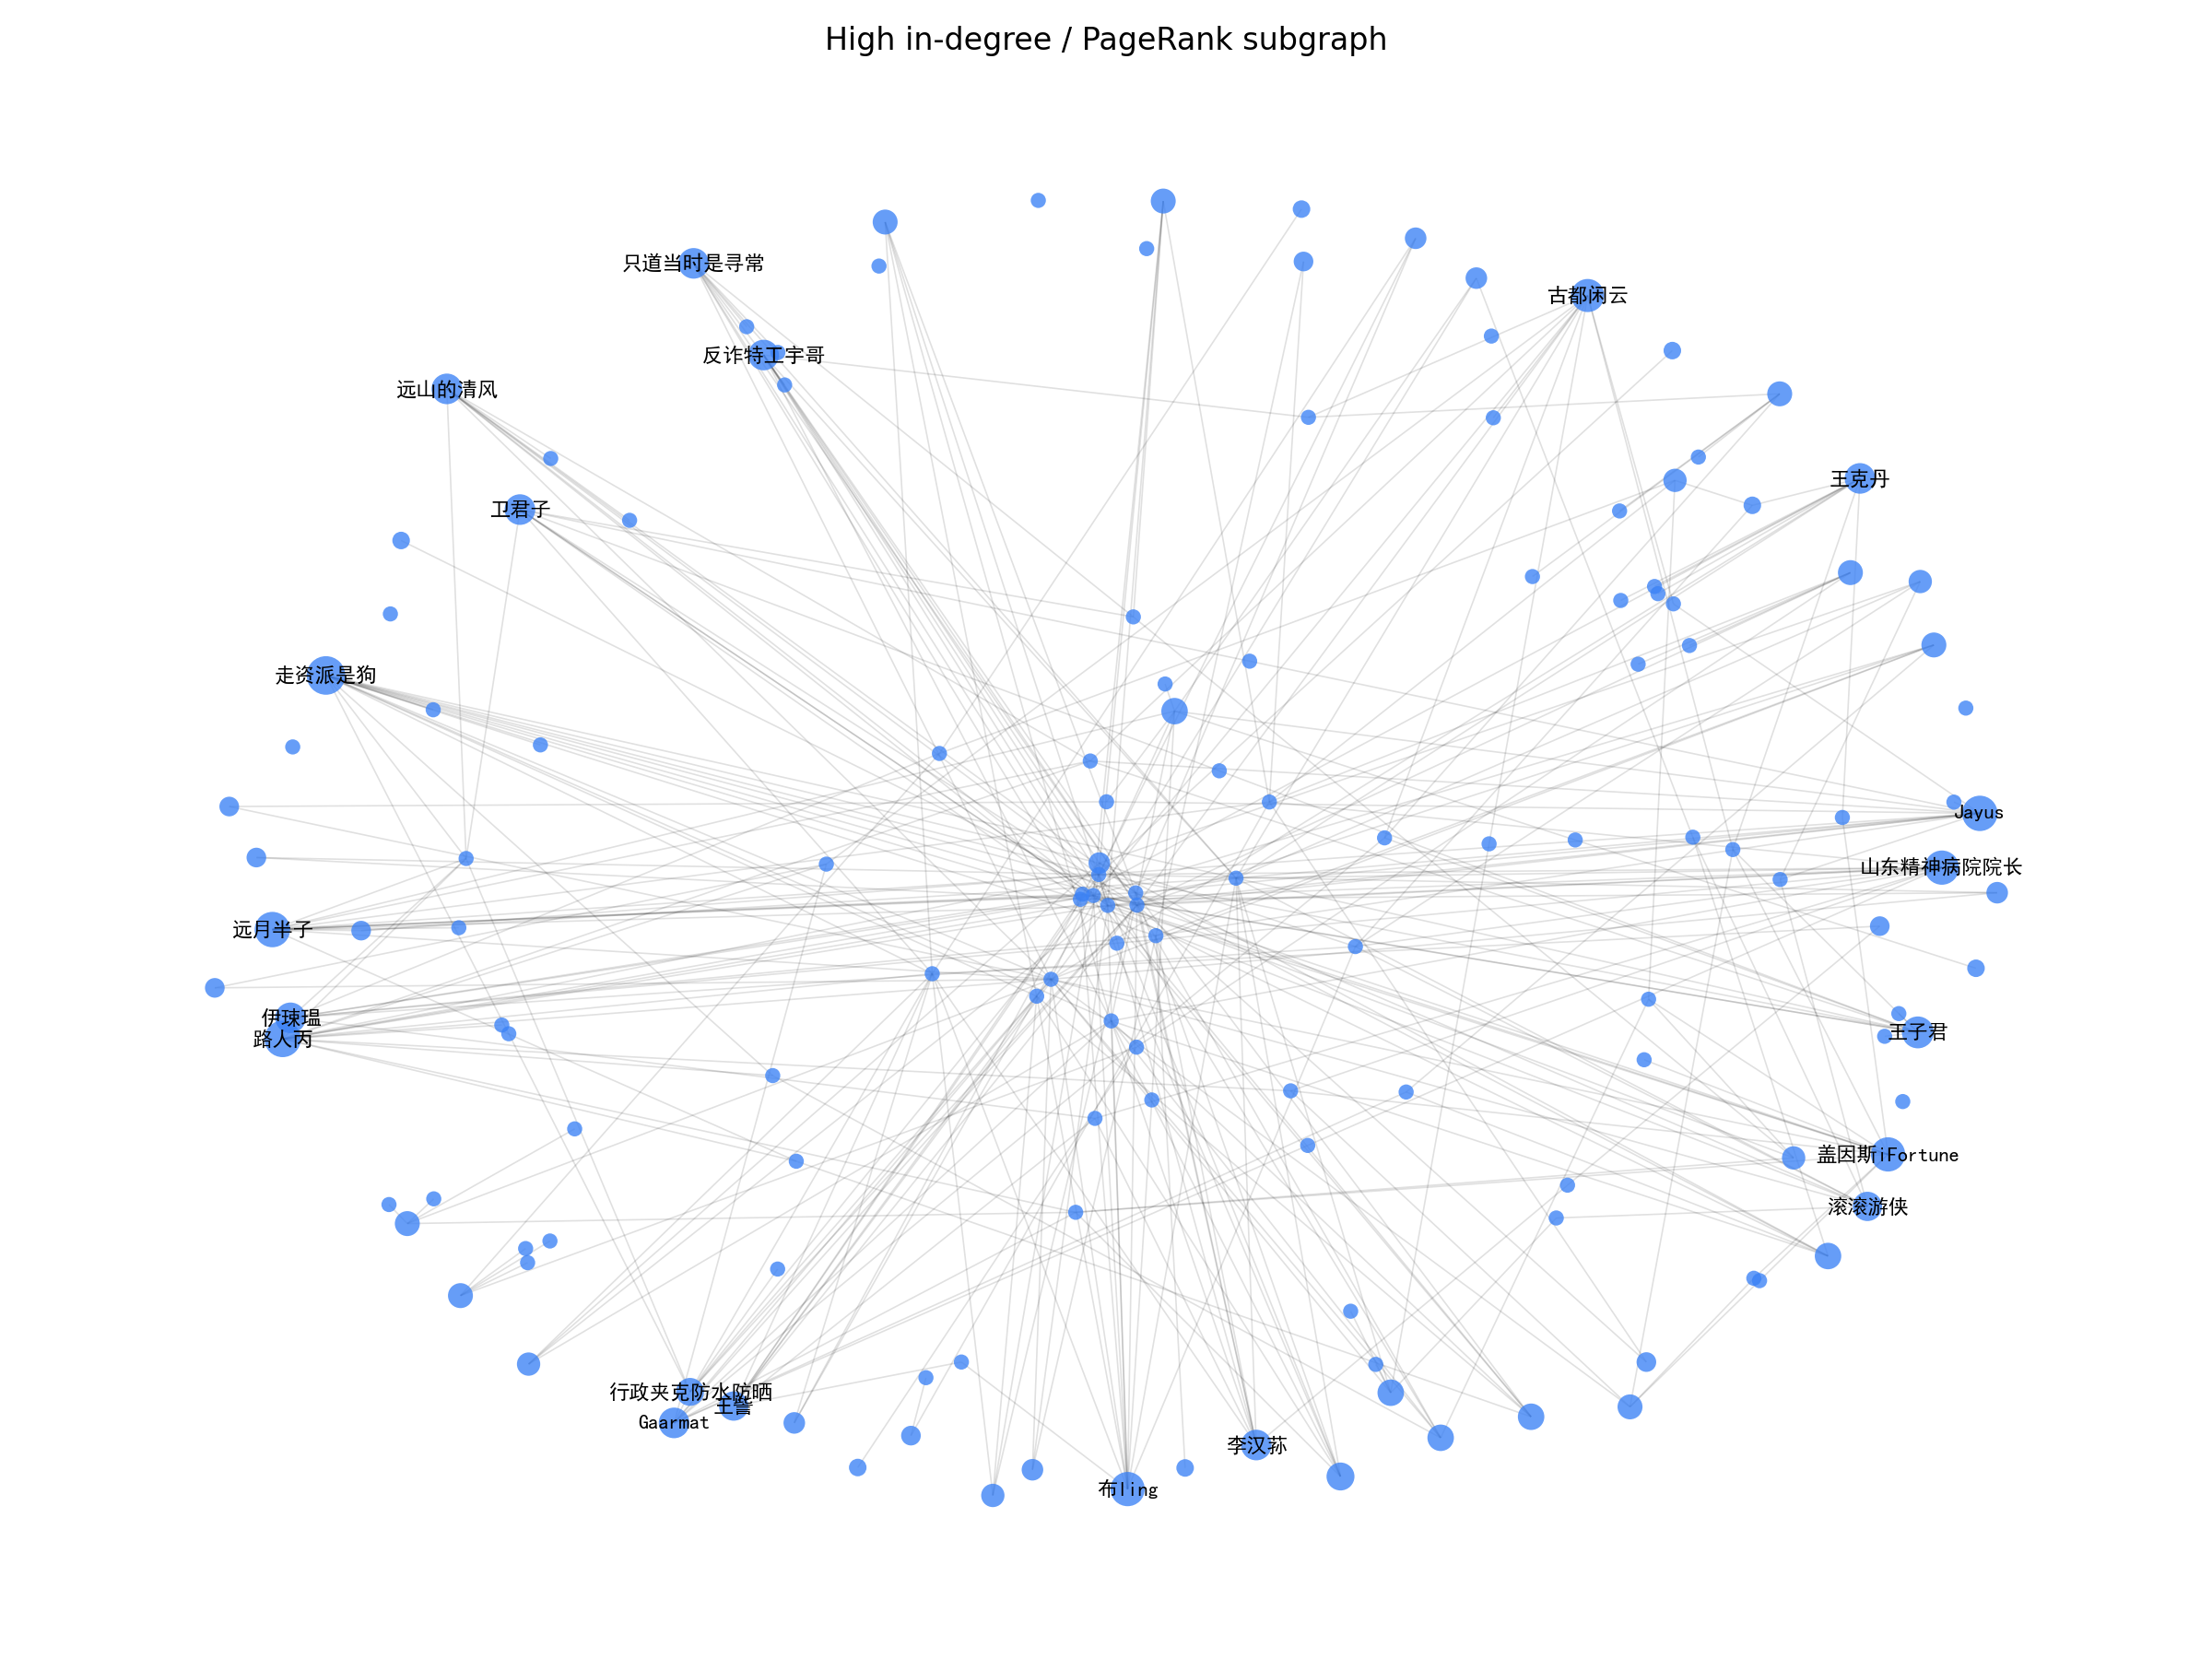

In [6]:
for image_path in [config.FULL_NETWORK_PNG, config.LEADER_SUBGRAPH_PNG]:
    if Path(image_path).exists():
        display(Image(filename=str(image_path)))
    else:
        print(f'未找到图像：{image_path}')